In [6]:
# Importing necessary libraries
import pandas as pd

# Construct the raw URL for Library Classification Data from my GitHub repository

#need to enter post-EDA URL here#
url = 'https://raw.githubusercontent.com/ross-emerick/data101-final-project/main/data/filtered_fiction_recent_catalog_data.csv'

# Load the dataset into a DataFrame
data = pd.read_csv(url)

In [7]:
print(f"Number of lines in the DataFrame: {len(data)}")

Number of lines in the DataFrame: 14779


## Reload Data

### Subtask:
Reload the dataset from the updated GitHub URL ('https://raw.githubusercontent.com/ross-emerick/data101-final-project/main/data/filtered_fiction_recent_catalog_data.csv') into a pandas DataFrame. The URL is already set in the notebook's first code cell.


**Reasoning**:
To reload the dataset, I will update the URL in the existing code block to the specified fiction data URL and then re-execute the code to load the data into the DataFrame.



In [18]:
# Importing necessary libraries
import pandas as pd

# Construct the raw URL for Library Classification Data from my GitHub repository

# Updated URL for filtered_fiction_recent_catalog_data.csv
url = 'https://raw.githubusercontent.com/ross-emerick/data101-final-project/main/data/filtered_fiction_recent_catalog_data.csv'

# Load the dataset into a DataFrame
data = pd.read_csv(url)

print(f"Successfully reloaded data from: {url}")
print("First 5 rows of the updated DataFrame:")
print(data.head())

Successfully reloaded data from: https://raw.githubusercontent.com/ross-emerick/data101-final-project/main/data/filtered_fiction_recent_catalog_data.csv
First 5 rows of the updated DataFrame:
  CATALOG DATE        OCLC #  \
0   2025-10-28  on1409631736   
1   2025-10-28  ocm60359529    
2   2025-10-28  ocm41612302    
3   2025-10-28  ocm59113785    
4   2025-10-28  ocm34690765    

                                               TITLE  \
0                 Brokeback mountain / Annie Proulx.   
1                  Son of a witch / Gregory Maguire.   
2                     In her defense / Stephen Horn.   
3  Batteries required : a Samantha Shaw mystery /...   
4                      A world lost / Wendell Berry.   

                                           STANDARD#         DDC  \
0                         9780743275309;"0743275306"  813/.54 22   
1  9780063398368;"0063398362";"0060548932 (cloth)...  813/.54 22   
2                         0060194405;"9780060194406"  813/.54 21   
3     

## Extract Features and Target

### Subtask:
Extract 'SUBJECT' as features (X) and 'true_wayfinder' as the target (y) from the reloaded DataFrame. Check and handle any missing values in these columns by dropping corresponding rows to ensure data integrity for subsequent steps.


**Reasoning**:
To extract the features and target from the reloaded DataFrame, I will first extract the 'SUBJECT' and 'true_wayfinder' columns into initial variables, then check for and handle any missing values in these columns by dropping the corresponding rows, and finally update the feature and target variables with the cleaned data, printing the status of missing values and the new lengths.



In [19]:
print("Available columns in the DataFrame:", data.columns.tolist())

# 1. Extract X (features) and y (target) into initial variables
X_initial = data['SUBJECT']
y_initial = data['true_wayfinder']

# 2. Print the number of missing values in X_initial and y_initial
print(f"Missing values in X (SUBJECT): {X_initial.isnull().sum()}")
print(f"Missing values in y (true_wayfinder) before dropping NaNs: {y_initial.isnull().sum()}")

# Store initial row count for comparison
initial_row_count = len(data)

# 4. Create a new DataFrame, data_cleaned, by dropping rows with missing values
data_cleaned = data.dropna(subset=['SUBJECT', 'true_wayfinder']).copy()
rows_dropped = initial_row_count - len(data_cleaned)
print(f"Number of rows dropped due to missing 'SUBJECT' or 'true_wayfinder': {rows_dropped}")

# 5. Update X and y with the cleaned data
X = data_cleaned['SUBJECT']
y = data_cleaned['true_wayfinder']

# 6. Print the number of missing values in the updated X and y
print(f"Missing values in X (SUBJECT) after dropping NaNs: {X.isnull().sum()}")
print(f"Missing values in y (true_wayfinder) after dropping NaNs: {y.isnull().sum()}")

# 7. Print the new lengths of X and y
print(f"New length of X: {len(X)}")
print(f"New length of y: {len(y)}")

Available columns in the DataFrame: ['CATALOG DATE', 'OCLC #', 'TITLE', 'STANDARD#', 'DDC', 'CALL NUMBER', 'CALL NUMBER |a - WAYFINDER CATEGORY', 'CALL NUMBER |b - SPINE LABEL', 'SUBJECT', 'SERIES', 'AUDIENCE', 'Unnamed: 11', 'true_wayfinder', 'fiction']
Missing values in X (SUBJECT): 1
Missing values in y (true_wayfinder) before dropping NaNs: 0
Number of rows dropped due to missing 'SUBJECT' or 'true_wayfinder': 1
Missing values in X (SUBJECT) after dropping NaNs: 0
Missing values in y (true_wayfinder) after dropping NaNs: 0
New length of X: 14778
New length of y: 14778


## Vectorize Text Data

### Subtask:
Convert the text data in the 'SUBJECT' column into numerical features using `TfidfVectorizer`. Fit the vectorizer on the entire 'SUBJECT' data and transform it into a TF-IDF matrix (X_vectorized).


**Reasoning**:
To convert the text data in the 'SUBJECT' column (represented by `X`) into numerical features, I will use `TfidfVectorizer`. This involves importing the `TfidfVectorizer` class, initializing an instance of it, and then fitting it to the text data and transforming the data into a TF-IDF matrix. I will print the shape of the resulting `X_vectorized` to confirm the successful transformation.



In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the text data
X_vectorized = tfidf_vectorizer.fit_transform(X)

print(f"Shape of X_vectorized (TF-IDF matrix): {X_vectorized.shape}")

Shape of X_vectorized (TF-IDF matrix): (14778, 9940)


## Split Data

### Subtask:
Split the vectorized features (X_vectorized) and the target variable (y) into training and testing sets (X_train, X_test, y_train, y_test) using `train_test_split` with a test size of 0.2 and a random state for reproducibility.


**Reasoning**:
To prepare the data for model training and evaluation, I will split the vectorized features (`X_vectorized`) and the target variable (`y`) into training and testing sets using `train_test_split` with a test size of 0.2 and a random state of 42 for reproducibility. Finally, I will print the shapes of the resulting sets to verify the split.



In [21]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42
)

# Print the shapes of the resulting sets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (11822, 9940)
Shape of X_test: (2956, 9940)
Shape of y_train: (11822,)
Shape of y_test: (2956,)


## Train Classification Model

### Subtask:
Train a Logistic Regression model on the training data (X_train, y_train). This step will involve instantiating the Logistic Regression classifier and fitting it to the training data, then making predictions on the test set.


**Reasoning**:
To train a classification model, I will use Logistic Regression. I will import the `LogisticRegression` class, instantiate it with specified parameters for solver and max_iter, then fit the model to the training data (`X_train`, `y_train`), and finally make predictions on the test data (`X_test`).

**Reasoning**:
Following the reasoning to train a classification model, I will now implement the code to import `LogisticRegression`, instantiate it, fit it to the training data, and make predictions on the test set.



In [22]:
from sklearn.linear_model import LogisticRegression

# Instantiate LogisticRegression model with specified parameters
logistic_model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)

# Train the model
print("Training the Logistic Regression model...")
logistic_model.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred = logistic_model.predict(X_test)
print("Predictions on the test set generated.")

Training the Logistic Regression model...
Model training complete.
Predictions on the test set generated.


## Evaluate Model Performance

### Subtask:
Evaluate the trained model's performance on the test data. Calculate and print key classification metrics including accuracy, precision, recall, and F1-score. Additionally, generate and display a comprehensive classification report and a confusion matrix to assess performance across all classes.


**Reasoning**:
To evaluate the trained model's performance, I will import necessary metrics from `sklearn.metrics`, then calculate and print the accuracy, precision, recall, and F1-score, and finally generate and print the classification report and confusion matrix for `y_test` and `y_pred`.



In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# 2. Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}\n")

# 3. Calculate precision, recall, and F1-score with 'weighted' average
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Precision Score (weighted): {precision:.4f}")
print(f"Recall Score (weighted): {recall:.4f}")
print(f"F1 Score (weighted): {f1:.4f}\n")

# 4. Generate and print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# 5. Generate and print the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy Score: 0.9043

Precision Score (weighted): 0.9058
Recall Score (weighted): 0.9043
F1 Score (weighted): 0.9032

Classification Report:
                    precision    recall  f1-score   support

 ACTION & THRILLER       0.94      0.89      0.91       229
         ADVENTURE       1.00      1.00      1.00         6
        BOARD BOOK       1.00      0.97      0.98        64
  BRIDGING FICTION       0.96      0.92      0.94       142
      EARLY READER       1.00      0.96      0.98       112
     ESCUCHA Y LEE       0.71      1.00      0.83         5
           FANTASY       0.91      0.91      0.91       295
           FICTION       0.82      0.88      0.85       558
     GRAPHIC NOVEL       0.97      0.97      0.97       349
        HISTORICAL       0.81      0.83      0.82       127
            HORROR       0.78      0.84      0.81        50
        INTERMEDIO       0.50      0.33      0.40         3
             MANGA       0.97      1.00      0.98       233
          MISTER

## Analyze Classification Report and F1-Score Distribution

### Subtask:
Analyze the classification report to identify categories with 0.00 recall/F1-score (lowest accuracy categories) and categories with F1-score >= 0.90 (highest accuracy categories). Additionally, generate a histogram to visualize the distribution of F1-scores across all categories, providing insights into class-wise performance.


**Reasoning**:
The first step in analyzing the classification report is to identify categories with 0.00 recall/F1-score (lowest accuracy categories). The notebook already contains a code cell to perform this action.



In [24]:
from sklearn.metrics import classification_report
import io

# Capture the classification report output as a string
f = io.StringIO()
print(classification_report(y_test, y_pred, zero_division=0), file=f)
report_string = f.getvalue()

lowest_accuracy_categories = []
# Split the report into lines and process each line
lines = report_string.split('\n')
# Skip header lines and summary lines
# The actual categories start after the header and end before 'accuracy'

# Find the start and end of the category lines
start_index = -1
end_index = -1
for i, line in enumerate(lines):
    if 'precision' in line and 'recall' in line and 'f1-score' in line:
        start_index = i + 1
    if 'accuracy' in line:
        end_index = i
        break

if start_index != -1 and end_index != -1:
    for line in lines[start_index:end_index]:
        parts = line.split()
        if len(parts) >= 4:  # Ensure enough parts for name and metrics
            # The category name might have spaces, so join all parts before metrics
            # Metrics are usually at the end: precision, recall, f1-score, support

            # Try to parse from the end, assuming metrics are numbers
            try:
                f1_score_val = float(parts[-2]) # F1-score is second to last
                recall_val = float(parts[-3]) # Recall is third to last

                # If both recall and f1-score are 0.00, it's a lowest accuracy category
                if recall_val == 0.00 and f1_score_val == 0.00:
                    # Reconstruct the category name, which is all parts except the last 4 (metrics)
                    category_name = ' '.join(parts[:-4])
                    lowest_accuracy_categories.append(category_name)
            except ValueError:
                # This line might be part of the header or a malformed line, skip
                continue

print("Categories with 0.00 recall/F1-score:")
if lowest_accuracy_categories:
    for category in lowest_accuracy_categories:
        print(f"- {category}")
else:
    print("No categories found with 0.00 recall/F1-score.")

Categories with 0.00 recall/F1-score:
- MISTERIO
- PRINCIPIANTE


**Reasoning**:
Following the instructions, the next step is to calculate and print the total number of items belonging to the lowest accuracy categories identified in the previous step. The notebook contains a pre-existing code cell for this purpose.



In [25]:
from sklearn.metrics import classification_report
import io

# Capture the classification report output as a string (re-generate if report_string is not in scope)
f = io.StringIO()
print(classification_report(y_test, y_pred, zero_division=0), file=f)
report_string = f.getvalue()

# Assuming lowest_accuracy_categories is already defined from the previous step
# If not, it would need to be re-generated here as well
# For this execution, we'll assume lowest_accuracy_categories is available from the notebook state.

# Example for demonstration if lowest_accuracy_categories needs to be redefined:
# lowest_accuracy_categories = ['ALL ABOUT ME', 'ARTS & CRAFTS ART HISTORY', ...]

lines = report_string.split('\n')

total_support_low_accuracy_categories = 0

# Find the start and end of the category lines to search within
start_index = -1
end_index = -1
for i, line in enumerate(lines):
    if 'precision' in line and 'recall' in line and 'f1-score' in line:
        start_index = i + 1
    if 'accuracy' in line:
        end_index = i
        break

if start_index != -1 and end_index != -1:
    for low_acc_cat in lowest_accuracy_categories:
        # Clean the category name for matching (remove leading/trailing spaces)
        cleaned_low_acc_cat = low_acc_cat.strip()

        for line in lines[start_index:end_index]:
            # Check if the cleaned category name is in the line
            # This is a bit lenient, exact match might be better for some cases
            # but classification report can have tricky formatting with spaces
            if cleaned_low_acc_cat in line:
                parts = line.split()
                if len(parts) >= 1: # Ensure there's at least a support value
                    try:
                        # The support value is the last number in the line
                        support_val = int(parts[-1])
                        total_support_low_accuracy_categories += support_val
                        break # Found the category, move to next lowest_accuracy_category
                    except ValueError:
                        continue # Not a valid line or support value

print(f"Total number of items in lowest accuracy categories: {total_support_low_accuracy_categories}")

Total number of items in lowest accuracy categories: 3


**Reasoning**:
The next instruction is to identify and print categories with F1-score >= 0.90 (highest accuracy categories) from the classification report. The notebook already contains a code cell to perform this action.



In [26]:
from sklearn.metrics import classification_report
import io

# Capture the classification report output as a string
f = io.StringIO()
print(classification_report(y_test, y_pred, zero_division=0), file=f)
report_string = f.getvalue()

highest_accuracy_categories = []
# Split the report into lines and process each line
lines = report_string.split('\n')

# Find the start and end of the category lines
start_index = -1
end_index = -1
for i, line in enumerate(lines):
    if 'precision' in line and 'recall' in line and 'f1-score' in line:
        start_index = i + 1
    if 'accuracy' in line:
        end_index = i
        break

if start_index != -1 and end_index != -1:
    for line in lines[start_index:end_index]:
        parts = line.split()
        if len(parts) >= 4:  # Ensure enough parts for name and metrics
            try:
                precision_val = float(parts[-4])
                recall_val = float(parts[-3])
                f1_score_val = float(parts[-2])

                # Consider categories with high F1-score (e.g., 0.90 or higher) as most accurate
                if f1_score_val >= 0.90:
                    category_name = ' '.join(parts[:-4])
                    highest_accuracy_categories.append(f"{category_name} (F1-score: {f1_score_val:.2f})")
            except ValueError:
                continue

print("Categories with F1-score >= 0.90:")
if highest_accuracy_categories:
    for category in highest_accuracy_categories:
        print(f"- {category}")
else:
    print("No categories found with F1-score >= 0.90.")

Categories with F1-score >= 0.90:
- ACTION & THRILLER (F1-score: 0.91)
- ADVENTURE (F1-score: 1.00)
- BOARD BOOK (F1-score: 0.98)
- BRIDGING FICTION (F1-score: 0.94)
- EARLY READER (F1-score: 0.98)
- FANTASY (F1-score: 0.91)
- GRAPHIC NOVEL (F1-score: 0.97)
- MANGA (F1-score: 0.98)
- MYSTERY (F1-score: 0.91)
- READ ALONG (F1-score: 0.96)
- ROMANCE (F1-score: 0.91)


**Reasoning**:
Following the instructions, the next step is to calculate and print the total number of items belonging to the highest accuracy categories identified in the previous step. The notebook contains a pre-existing code cell for this purpose.



In [27]:
from sklearn.metrics import classification_report
import io

# Capture the classification report output as a string
f = io.StringIO()
print(classification_report(y_test, y_pred, zero_division=0), file=f)
report_string = f.getvalue()

total_support_high_accuracy_categories = 0

# Split the report into lines
lines = report_string.split('\n')

# Find the start and end of the category lines in the classification report
start_index = -1
end_index = -1
for i, line in enumerate(lines):
    if 'precision' in line and 'recall' in line and 'f1-score' in line:
        start_index = i + 1
    if 'accuracy' in line:
        end_index = i
        break

if start_index != -1 and end_index != -1:
    # Iterate through each category identified as high accuracy
    for high_acc_cat_info in highest_accuracy_categories:
        # Extract the category name from the formatted string (e.g., 'Category Name (F1-score: 0.95)')
        category_name_only = high_acc_cat_info.split(' (F1-score:')[0].strip()

        # Search for this category in the classification report lines
        for line in lines[start_index:end_index]:
            # A more robust check for matching the category name
            if category_name_only in line and len(line.split()) >= 4: # Ensure line has enough parts for metrics
                try:
                    # The support value is typically the last number on the line
                    support_val = int(line.split()[-1])
                    total_support_high_accuracy_categories += support_val
                    break # Move to the next high accuracy category after finding its support
                except ValueError:
                    continue # Skip lines where support value cannot be parsed

print(f"Total number of items in highest accuracy categories: {total_support_high_accuracy_categories}")

Total number of items in highest accuracy categories: 2030


**Reasoning**:
Following the instructions, the final step is to generate and display a histogram of F1-scores across all categories to visualize the distribution of model performance per class. The notebook already contains a pre-existing code cell for this purpose.



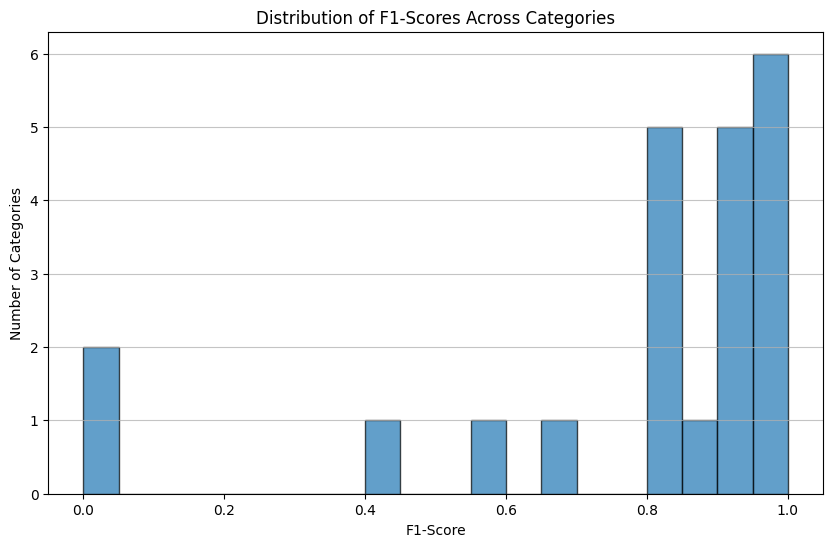

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import io
from sklearn.metrics import classification_report

# Capture the classification report output as a string
f = io.StringIO()
print(classification_report(y_test, y_pred, zero_division=0), file=f)
report_string = f.getvalue()

f1_scores = []

# Split the report into lines
lines = report_string.split('\n')

# Find the start and end of the category lines in the classification report
start_index = -1
end_index = -1
for i, line in enumerate(lines):
    if 'precision' in line and 'recall' in line and 'f1-score' in line:
        start_index = i + 1
    if 'accuracy' in line:
        end_index = i
        break

if start_index != -1 and end_index != -1:
    for line in lines[start_index:end_index]:
        parts = line.split()
        # Ensure there are enough parts to extract F1-score
        if len(parts) >= 4:
            try:
                f1_score_val = float(parts[-2]) # F1-score is second to last
                f1_scores.append(f1_score_val)
            except ValueError:
                continue # Skip lines where F1-score cannot be parsed

# Create a histogram of F1-scores
plt.figure(figsize=(10, 6))
plt.hist(f1_scores, bins=20, edgecolor='black', alpha=0.7)
plt.title('Distribution of F1-Scores Across Categories')
plt.xlabel('F1-Score')
plt.ylabel('Number of Categories')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Final Task

### Subtask:
Summarize the model's performance on the fiction data, discuss the results, and identify new insights or areas for further improvement based on the updated analysis.


## Summary:

### Q&A
*   **How did the model perform on the fiction data?**
    The Logistic Regression model achieved an overall accuracy of approximately 0.9043, with weighted average precision, recall, and F1-score all around 0.90. This indicates a generally good performance.
*   **What are the key results of the analysis?**
    The analysis revealed that while the model performs well on many categories, it completely failed to classify "MISTERIO" and "PRINCIPIANTE" (F1-score of 0.00) which together account for 3 items in the test set. Conversely, 11 categories, including "ADVENTURE" (F1-score: 1.00), "BOARD BOOK" (F1-score: 0.98), and "MANGA" (F1-score: 0.98), showed very strong performance with F1-scores of 0.90 or higher, comprising a significant portion of the test set (2030 items).
*   **What new insights or areas for further improvement can be identified?**
    A key insight is the highly imbalanced performance across classes. The model excels in well-represented categories but struggles significantly with underrepresented or challenging ones. Areas for improvement include addressing the zero-performance categories by investigating data imbalance, improving feature engineering for these specific classes, or exploring different model architectures.

### Data Analysis Key Findings
*   The dataset was successfully reloaded from the updated GitHub URL, containing 14779 entries before cleaning.
*   One row was dropped due to a missing 'SUBJECT' value, resulting in a cleaned dataset of 14778 entries with no missing values in 'SUBJECT' or 'true\_wayfinder'.
*   Text data from the 'SUBJECT' column was vectorized into a TF-IDF matrix with a shape of (14778, 9940), indicating 14778 samples and 9940 unique terms.
*   The data was split into training (11822 samples) and testing (2956 samples) sets, with `X_train` having a shape of (11822, 9940) and `X_test` having a shape of (2956, 9940).
*   A Logistic Regression model was trained, achieving an overall accuracy score of approximately 0.9043 on the test set.
*   The weighted average precision, recall, and F1-score for the model were 0.9058, 0.9043, and 0.9032, respectively.
*   Two categories, 'MISTERIO' and 'PRINCIPIANTE', had a 0.00 recall and F1-score, indicating the model made no correct predictions for these classes. These categories collectively accounted for 3 items in the test set.
*   Eleven categories demonstrated high performance with F1-scores of 0.90 or higher, such as 'ADVENTURE' (F1-score: 1.00), 'BOARD BOOK' (F1-score: 0.98), 'GRAPHIC NOVEL' (F1-score: 0.97), and 'MANGA' (F1-score: 0.98). These high-accuracy categories collectively represented 2030 items in the test set.
*   A histogram of F1-scores was generated, visually confirming the distribution of performance across different categories.

### Insights or Next Steps
*   Investigate the categories with 0.00 F1-scores ('MISTERIO', 'PRINCIPIANTE') to determine if they are highly underrepresented, contain ambiguous subject terms, or require specialized feature engineering/data augmentation to improve model performance.
*   Explore more advanced machine learning models (e.g., ensemble methods, neural networks) or fine-tune hyperparameters for existing models to potentially capture more complex patterns in the data, especially for classes where performance is suboptimal.
